## Import Required Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Define Dataset Paths

In [2]:
from pathlib import Path

ROOT = Path("..")

DATA_DIR = ROOT / "data"

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

RECORDINGS_DIR = DATA_DIR / "recordings"

TRAIN_TEXT = TRAIN_DIR / "text.txt"
TRAIN_UTT2SPK = TRAIN_DIR / "utt2spk.txt"
TRAIN_WAV_SCP = TRAIN_DIR / "wav.scp"

TEST_TEXT = TEST_DIR / "text.txt"
TEST_UTT2SPK = TEST_DIR / "utt2spk.txt"
TEST_WAV_SCP = TEST_DIR / "wav.scp"

## Create a Kaldi-Style Metadata Reader

In [3]:
def read_file(path):
    data = {}

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)

            if len(parts) == 2:
                key, value = parts
                data[key] = value

    return data

## Load Training and Test Metadata

In [4]:
train_text = read_file(TRAIN_TEXT)
train_utt2spk = read_file(TRAIN_UTT2SPK)
train_wav = read_file(TRAIN_WAV_SCP)

test_text = read_file(TEST_TEXT)
test_utt2spk = read_file(TEST_UTT2SPK)
test_wav = read_file(TEST_WAV_SCP)

## Inspect a Sample Utterance ID

In [5]:
print(list(train_text)[0])

ThantSinTun_20260901_091117


## Build DataFrames from Speech Metadata

In [6]:
def create_dataframe(text, utt2spk, wav):
    rows = []

    for utt_id in text:
        rows.append({
            "utt_id": utt_id,
            "speaker": utt2spk[utt_id],
            "wav": wav[utt_id],
            "text": text[utt_id]
        })

    return pd.DataFrame(rows)

## Create Training and Test DataFrames

In [7]:
train_df = create_dataframe(
    train_text,
    train_utt2spk,
    train_wav
)

test_df = create_dataframe(
    test_text,
    test_utt2spk,
    test_wav
)

## Preview the Training Data

In [8]:
train_df.head()

,utt_id,speaker,wav,text
0,ThantSinTun_20260901_091117,ThantSinTun,recordings/ThantSinTun/ThantSinTun_20260901_09...,၀
1,ThantSinTun_20260901_091140,ThantSinTun,recordings/ThantSinTun/ThantSinTun_20260901_09...,၁
2,ThantSinTun_20260901_091159,ThantSinTun,recordings/ThantSinTun/ThantSinTun_20260901_09...,၂
3,ThantSinTun_20260901_091242,ThantSinTun,recordings/ThantSinTun/ThantSinTun_20260901_09...,၃
4,ThantSinTun_20260901_091305,ThantSinTun,recordings/ThantSinTun/ThantSinTun_20260901_09...,၄


## Verify the Notebook Working Directory

In [9]:
print("Current Working Directory:", os.getcwd())

Current Working Directory: c:\Users\onest\OneDrive\Desktop\Projects\MM_Num_ASR\notebooks


## Load and Inspect a Training Audio File

In [10]:
wav_path = Path(DATA_DIR) / train_df.iloc[0]["wav"]

audio, sr = librosa.load(
    wav_path,
    sr=None
)

print("Sample rate:", sr)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / sr)

c:\Users\onest\miniconda3\envs\pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample rate: 16000
Number of samples: 92352
Duration: 5.772


## Visualize the Speech Waveform

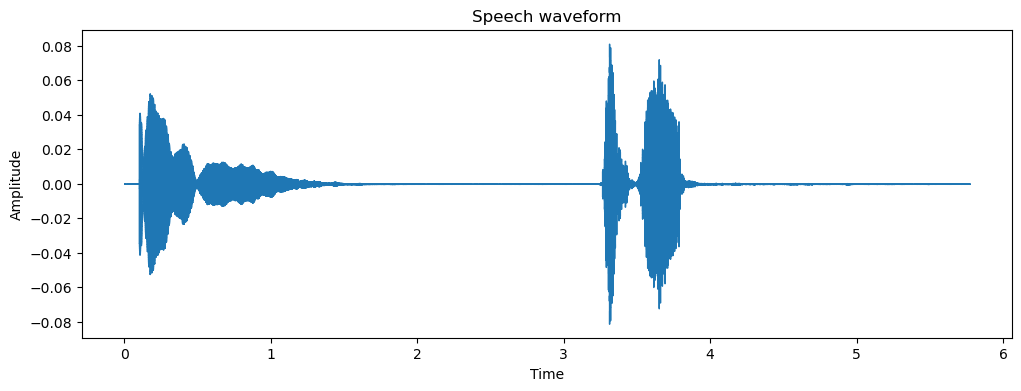

In [11]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(audio, sr=sr)

plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Speech waveform")
plt.show()

## Define MFCC Feature Extraction

In [12]:
def extract_mfcc(
    wav_path,
    sr=16000,
    n_mfcc=13,
    n_fft=512,
    hop_length=160
):
    audio, _ = librosa.load(
        wav_path,
        sr=sr,
        mono=True
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )

    return mfcc.T

## Extract MFCC Features from a Sample

In [13]:
# Get the first training audio path
wav_path = Path(DATA_DIR) / train_df.iloc[0]["wav"]

# Extract MFCC features
mfcc = extract_mfcc(wav_path)

print("MFCC shape:", mfcc.shape)
print("Number of frames:", mfcc.shape[0])
print("Number of features:", mfcc.shape[1])

MFCC shape: (578, 13)
Number of frames: 578
Number of features: 13


## Visualize the MFCC Features

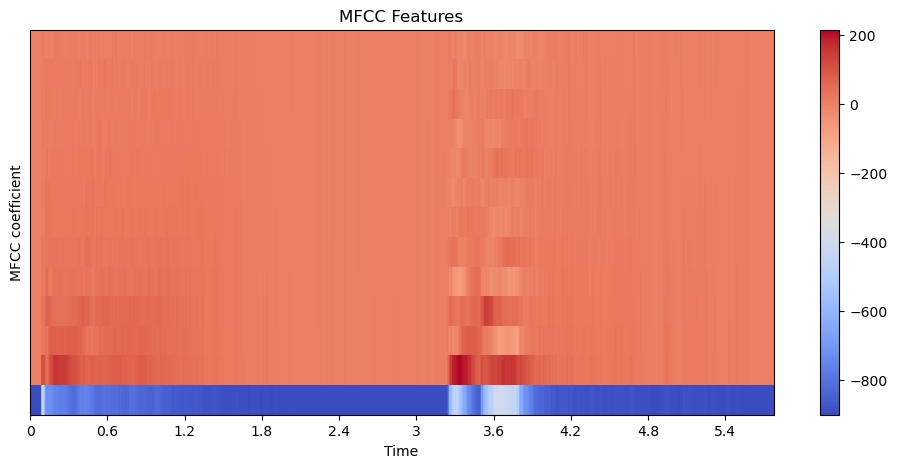

In [14]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc.T,
    sr=16000,
    hop_length=160,
    x_axis="time"
)

plt.colorbar()
plt.xlabel("Time")
plt.ylabel("MFCC coefficient")
plt.title("MFCC Features")
plt.show()

## Build the Character Vocabulary

In [15]:
all_text = " ".join(train_df["text"].astype(str))

characters = sorted(set(all_text))

print("Number of unique characters:", len(characters))
print(characters)

Number of unique characters: 49
[' ', ',', 'က', 'ခ', 'ဂ', 'င', 'စ', 'ဇ', 'ည', 'တ', 'ထ', 'ဒ', 'န', 'ပ', 'ဖ', 'ဘ', 'မ', 'ယ', 'ရ', 'လ', 'ဝ', 'အ', 'ဧ', 'ဩ', 'ါ', 'ာ', 'ိ', 'ီ', 'ု', 'ူ', 'ေ', 'ဲ', 'ံ', 'း', '်', 'ျ', 'ြ', 'ွ', 'ှ', '၀', '၁', '၂', '၃', '၄', '၅', '၆', '၇', '၈', '၉']


## Map Characters to CTC Token IDs

In [16]:
BLANK_ID = 0
UNK_ID = 1

char_to_id = {
    "<blank>": BLANK_ID,
    "<unk>": UNK_ID
}

for char in characters:
    if char not in char_to_id:
        char_to_id[char] = len(char_to_id)

id_to_char = {
    idx: char
    for char, idx in char_to_id.items()
}

print("Vocabulary size:", len(char_to_id))
print(char_to_id)

Vocabulary size: 51
{'<blank>': 0, '<unk>': 1, ' ': 2, ',': 3, 'က': 4, 'ခ': 5, 'ဂ': 6, 'င': 7, 'စ': 8, 'ဇ': 9, 'ည': 10, 'တ': 11, 'ထ': 12, 'ဒ': 13, 'န': 14, 'ပ': 15, 'ဖ': 16, 'ဘ': 17, 'မ': 18, 'ယ': 19, 'ရ': 20, 'လ': 21, 'ဝ': 22, 'အ': 23, 'ဧ': 24, 'ဩ': 25, 'ါ': 26, 'ာ': 27, 'ိ': 28, 'ီ': 29, 'ု': 30, 'ူ': 31, 'ေ': 32, 'ဲ': 33, 'ံ': 34, 'း': 35, '်': 36, 'ျ': 37, 'ြ': 38, 'ွ': 39, 'ှ': 40, '၀': 41, '၁': 42, '၂': 43, '၃': 44, '၄': 45, '၅': 46, '၆': 47, '၇': 48, '၈': 49, '၉': 50}


## Convert Transcripts into Label IDs

In [17]:
def text_to_ids(text):
    return [
        char_to_id.get(char, UNK_ID)
        for char in text
    ]


train_df["labels"] = train_df["text"].apply(text_to_ids)
test_df["labels"] = test_df["text"].apply(text_to_ids)

print("Text:", train_df.iloc[0]["text"])
print("Labels:", train_df.iloc[0]["labels"])

Text: ၀
Labels: [41]


## Validate WAV File Paths

In [18]:
def get_wav_path(wav_value):
    wav_path = DATA_DIR / str(wav_value)

    if not wav_path.exists():
        raise FileNotFoundError(
            f"WAV file not found:\n{wav_path}"
        )

    return wav_path


test_path = get_wav_path(train_df.iloc[0]["wav"])

print("WAV path:", test_path)
print("Exists:", test_path.exists())

WAV path: ..\data\recordings\ThantSinTun\ThantSinTun_20260901_091117.wav
Exists: True


## Define the ASR Dataset

In [19]:
class ASRDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wav_path = get_wav_path(row["wav"])

        features = extract_mfcc(wav_path)

        features = torch.tensor(
            features,
            dtype=torch.float32
        )

        labels = torch.tensor(
            row["labels"],
            dtype=torch.long
        )

        return features, labels

## Inspect One Dataset Example

In [20]:
train_dataset = ASRDataset(train_df)

features, labels = train_dataset[0]

print("Feature shape:", features.shape)
print("Label shape:", labels.shape)

print("Feature dtype:", features.dtype)
print("Label dtype:", labels.dtype)

print("Labels:", labels)

Feature shape: torch.Size([578, 13])
Label shape: torch.Size([1])
Feature dtype: torch.float32
Label dtype: torch.int64
Labels: tensor([41])


## Pad Variable-Length Batches

In [21]:
def collate_fn(batch):

    features, labels = zip(*batch)

    feature_lengths = torch.tensor(
        [x.shape[0] for x in features],
        dtype=torch.long
    )

    label_lengths = torch.tensor(
        [y.shape[0] for y in labels],
        dtype=torch.long
    )

    padded_features = nn.utils.rnn.pad_sequence(
        features,
        batch_first=True
    )

    padded_labels = nn.utils.rnn.pad_sequence(
        labels,
        batch_first=True,
        padding_value=BLANK_ID
    )

    return (
        padded_features,
        padded_labels,
        feature_lengths,
        label_lengths
    )

## Create Training and Test DataLoaders

In [22]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

test_dataset = ASRDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 3149
Testing samples: 1502


## Inspect a Padded Training Batch

In [23]:
features, labels, feature_lengths, label_lengths = next(iter(train_loader))

print("Features:", features.shape)
print("Labels:", labels.shape)

print("Feature lengths:", feature_lengths)
print("Label lengths:", label_lengths)

Features: torch.Size([16, 1607, 13])
Labels: torch.Size([16, 28])
Feature lengths: tensor([ 380,  931,  744,  367,  307,  281,  768,  469, 1607,  679,  157,  827,
         843,  383,  406,  926])
Label lengths: tensor([11, 28,  3,  2,  5,  2, 12, 20, 25, 21,  2,  3, 11, 16,  3, 28])


## Recheck Constructed Audio Paths

In [24]:
print("DATA_DIR:")
print(DATA_DIR)

print("\nStored WAV value:")
print(train_df.iloc[0]["wav"])

print("\nConstructed path:")
print(get_wav_path(train_df.iloc[0]["wav"]))

print("\nExists:")
print(get_wav_path(train_df.iloc[0]["wav"]).exists())

DATA_DIR:
..\data

Stored WAV value:
recordings/ThantSinTun/ThantSinTun_20260901_091117.wav

Constructed path:
..\data\recordings\ThantSinTun\ThantSinTun_20260901_091117.wav

Exists:
True


## Compute Feature Normalization Statistics

In [25]:
feature_sum = 0.0
feature_squared_sum = 0.0
total_frames = 0

for features, _, feature_lengths, _ in train_loader:

    for i, length in enumerate(feature_lengths):

        x = features[i, :length]

        feature_sum += x.sum(dim=0)
        feature_squared_sum += (x ** 2).sum(dim=0)

        total_frames += length.item()

mean = feature_sum / total_frames

variance = (
    feature_squared_sum / total_frames
    - mean ** 2
)

std = torch.sqrt(
    torch.clamp(variance, min=1e-8)
)

print("Mean:", mean)
print("Std:", std)

Mean: tensor([-7.2723e+02,  5.2290e+01,  7.1993e+00,  1.6864e+01, -4.3525e+00,
         5.0518e+00, -2.2942e+00,  1.7503e+00,  1.3583e+00, -1.1536e+00,
        -6.6236e-01, -9.0889e-01, -2.1059e+00])
Std: tensor([175.3614,  60.0336,  32.0374,  28.5009,  24.4833,  17.7681,  16.5634,
         12.3633,  11.4343,  11.6074,  10.4948,   9.7461,   9.3678])


## Add Feature Normalization to the Dataset

In [26]:
class ASRDataset(Dataset):

    def __init__(self, dataframe, mean=None, std=None):
        self.df = dataframe.reset_index(drop=True)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wav_path = get_wav_path(row["wav"])

        features = extract_mfcc(wav_path)

        features = torch.tensor(
            features,
            dtype=torch.float32
        )

        if self.mean is not None and self.std is not None:
            features = (features - self.mean) / self.std

        labels = torch.tensor(
            row["labels"],
            dtype=torch.long
        )

        return features, labels

## Rebuild Normalized DataLoaders

In [27]:
train_dataset = ASRDataset(
    train_df,
    mean=mean,
    std=std
)

test_dataset = ASRDataset(
    test_df,
    mean=mean,
    std=std
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

## Define the DNN Acoustic Model

In [31]:
class DNNASR(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        vocab_size
    ):
        super().__init__()

        # Downsamples the time axis twice (stride 2 each) so the LSTM
        # isn't asked to align labels against 500-1000+ raw frames.
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )

        self.classifier = nn.Linear(
            hidden_dim * 2,
            vocab_size
        )

    def forward(self, x):
        # x: [batch, time, input_dim] -> Conv1d wants [batch, channels, time]
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)  # back to [batch, time', hidden_dim]

        x, _ = self.lstm(x)

        logits = self.classifier(x)

        return logits

    @staticmethod
    def output_lengths(input_lengths):
        """Recompute sequence lengths after the two stride-2 conv layers."""
        lengths = input_lengths
        for _ in range(2):
            lengths = torch.div(lengths - 1, 2, rounding_mode="floor") + 1
        return lengths

## Configure Model Dimensions and Device

In [32]:
INPUT_DIM = 13
HIDDEN_DIM = 128
VOCAB_SIZE = len(char_to_id)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Input dimension:", INPUT_DIM)
print("Hidden dimension:", HIDDEN_DIM)
print("Vocabulary size:", VOCAB_SIZE)

Device: cuda
Input dimension: 13
Hidden dimension: 128
Vocabulary size: 51


## Initialize the DNN ASR Model

In [33]:
model = DNNASR(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    vocab_size=VOCAB_SIZE
)

model = model.to(device)

print(model)

DNNASR(
  (conv): Sequential(
    (0): Conv1d(13, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(128, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (classifier): Linear(in_features=256, out_features=51, bias=True)
)


## Configure CTC Loss and the Optimizer

In [34]:
criterion = nn.CTCLoss(
    blank=BLANK_ID,
    zero_infinity=True
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("CTC loss:", criterion)
print("Optimizer:", optimizer)

CTC loss: CTCLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


## Run a Forward Pass Through the Model

In [35]:
features, labels, feature_lengths, label_lengths = next(
    iter(train_loader)
)

features = features.to(device)

logits = model(features)

print("Input shape:")
print(features.shape)

print("\nOutput shape:")
print(logits.shape)

Input shape:
torch.Size([16, 1444, 13])

Output shape:
torch.Size([16, 361, 51])


## Prepare Log Probabilities for CTC

In [36]:
log_probs = logits.log_softmax(dim=2)

log_probs = log_probs.transpose(0, 1)

print("CTC input shape:", log_probs.shape)

CTC input shape: torch.Size([361, 16, 51])


## Calculate a Sample CTC Loss

In [37]:
labels = labels.to(device)

output_lengths = model.output_lengths(feature_lengths)

loss = criterion(
    log_probs,
    labels,
    output_lengths,
    label_lengths
)

print("CTC Loss:", loss.item())

CTC Loss: 118.46492004394531


## Define One-Epoch CTC Training

In [38]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip_norm=5.0):

    model.train()

    total_loss = 0.0
    num_batches = 0
    num_inf_batches = 0

    for features, labels, feature_lengths, label_lengths in loader:

        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        logits = model(features)

        # Lengths must match the conv-downsampled time axis
        output_lengths = model.output_lengths(feature_lengths)

        # Convert to log probabilities
        log_probs = logits.log_softmax(dim=2)

        # CTC expects [time, batch, vocab]
        log_probs = log_probs.transpose(0, 1)

        # Calculate CTC loss
        loss = criterion(
            log_probs,
            labels,
            output_lengths,
            label_lengths
        )

        if torch.isinf(loss):
            # zero_infinity=True would silently zero this and skip the
            # update anyway — count it so you know how often it happens
            num_inf_batches += 1
            continue

        # Backpropagation
        loss.backward()

        # Prevent the early gradient spikes that push CTC into
        # a "predict blank everywhere" local minimum
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        # Update parameters
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    if num_inf_batches:
        print(f"  ({num_inf_batches} batch(es) skipped: inf loss)")

    return total_loss / max(num_batches, 1)

## Train the ASR Model

In [39]:
EPOCHS = 10

train_losses = []

for epoch in range(EPOCHS):

    loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    train_losses.append(loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Loss: {loss:.4f}"
    )

Epoch 1/10 - Loss: 6.4747
Epoch 2/10 - Loss: 3.1991
Epoch 3/10 - Loss: 2.6771
Epoch 4/10 - Loss: 2.1939
Epoch 5/10 - Loss: 1.6888
Epoch 6/10 - Loss: 1.2053
Epoch 7/10 - Loss: 0.8570
Epoch 8/10 - Loss: 0.5870
Epoch 9/10 - Loss: 0.4563
Epoch 10/10 - Loss: 0.3375


## Define CTC Greedy Decoding

In [40]:
def ctc_greedy_decode(logits, id_to_char, blank_id):

    predictions = torch.argmax(
        logits,
        dim=-1
    )

    decoded_texts = []

    for sequence in predictions:

        previous_id = None
        text = []

        for token_id in sequence:

            token_id = token_id.item()

            # Ignore blank
            if token_id == blank_id:
                previous_id = token_id
                continue

            # Collapse repeated tokens
            if token_id == previous_id:
                continue

            if token_id in id_to_char:
                text.append(id_to_char[token_id])

            previous_id = token_id

        decoded_texts.append("".join(text))

    return decoded_texts

## Test Greedy Decoding on a Batch

In [41]:
model.eval()

with torch.no_grad():

    features, labels, feature_lengths, label_lengths = next(
        iter(test_loader)
    )

    features = features.to(device)

    logits = model(features)

    predictions = ctc_greedy_decode(
        logits,
        id_to_char,
        BLANK_ID
    )

print("Predicted:")
print(predictions[0])

print("\nReference:")
print(test_df.iloc[0]["text"])

Predicted:
၁

Reference:
၀


## Define Word Error Rate Metrics

In [42]:
def edit_distance(reference, hypothesis):
    """
    Calculate Levenshtein edit distance
    between two sequences of words.
    """

    ref_len = len(reference)
    hyp_len = len(hypothesis)

    dp = np.zeros(
        (ref_len + 1, hyp_len + 1),
        dtype=np.int32
    )

    # Initialization
    for i in range(ref_len + 1):
        dp[i, 0] = i

    for j in range(hyp_len + 1):
        dp[0, j] = j

    # Dynamic programming
    for i in range(1, ref_len + 1):
        for j in range(1, hyp_len + 1):

            if reference[i - 1] == hypothesis[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i, j] = min(
                dp[i - 1, j] + 1,        # deletion
                dp[i, j - 1] + 1,        # insertion
                dp[i - 1, j - 1] + cost  # substitution
            )

    return dp[ref_len, hyp_len]


def calculate_wer(reference, hypothesis):
    """
    Word Error Rate:

        WER = edit distance / number of reference words
    """

    # Convert sentences into word sequences
    reference_words = reference.split()
    hypothesis_words = hypothesis.split()

    if len(reference_words) == 0:
        return 0.0 if len(hypothesis_words) == 0 else 1.0

    distance = edit_distance(
        reference_words,
        hypothesis_words
    )

    return distance / len(reference_words)

## Define Full-Set Model Evaluation

In [43]:
def evaluate_model(
    model,
    loader,
    test_df,
    id_to_char,
    blank_id,
    device
):

    model.eval()

    predictions = []
    references = []

    sample_index = 0

    with torch.no_grad():

        for features, labels, feature_lengths, label_lengths in loader:

            features = features.to(device)

            # Model prediction
            logits = model(features)

            # Decode
            batch_predictions = ctc_greedy_decode(
                logits,
                id_to_char,
                blank_id
            )

            # Store predictions
            predictions.extend(batch_predictions)

            # Get corresponding reference text
            batch_size = len(batch_predictions)

            for i in range(batch_size):

                reference = test_df.iloc[
                    sample_index + i
                ]["text"]

                references.append(reference)

            sample_index += batch_size

    return references, predictions

## Generate Test-Set Predictions

In [44]:
references, predictions = evaluate_model(
    model=model,
    loader=test_loader,
    test_df=test_df,
    id_to_char=id_to_char,
    blank_id=BLANK_ID,
    device=device
)

print("Number of test samples:", len(references))

Number of test samples: 1502


## Calculate Overall Test WER

In [58]:
total_word_distance = 0
total_reference_words = 0

for reference, prediction in zip(
    references,
    predictions
):

    reference_words = reference.split()
    prediction_words = prediction.split()

    total_word_distance += edit_distance(
        reference_words,
        prediction_words
    )
    total_reference_words += len(reference_words)


wer = (
    total_word_distance / total_reference_words
    if total_reference_words > 0
    else 0.0
)

print(f"Test WER: {wer:.4f}")
print(f"Test WER: {wer * 100:.2f}%")

Test WER: 0.8316
Test WER: 83.16%


## Review Sample Predictions and WER

In [53]:
for i in range(min(20, len(references))):

    print("=" * 60)

    print("Reference:")
    print(references[i])

    print("\nPrediction:")
    print(predictions[i])

    print(
        "\nWER:",
        f"{calculate_wer(references[i], predictions[i]):.4f}"
    )

Reference:
၀

Prediction:
၁

WER: 1.0000
Reference:
၁

Prediction:
၁

WER: 0.0000
Reference:
၂

Prediction:
၁၂

WER: 1.0000
Reference:
၃

Prediction:
၅

WER: 1.0000
Reference:
၄

Prediction:
၁၄

WER: 1.0000
Reference:
၅

Prediction:
၁

WER: 1.0000
Reference:
၆

Prediction:
၆

WER: 0.0000
Reference:
၇

Prediction:
၇

WER: 0.0000
Reference:
၈

Prediction:
၈

WER: 0.0000
Reference:
၉

Prediction:
၃

WER: 1.0000
Reference:
နံပါတ် ၀ ပါ

Prediction:
နံပါတ် ပါ

WER: 0.3333
Reference:
နံပါတ် ၁ ပါ

Prediction:
နံပါတ် ပါ

WER: 0.3333
Reference:
နံပါတ် ၂ ပါ

Prediction:
နံပါတ် ၂ပါ

WER: 0.6667
Reference:
နံပါတ် ၃ ပါ

Prediction:
နံပါ၅ပါ

WER: 1.0000
Reference:
နံပါတ် ၄ ပါ

Prediction:
နံပါတ၄ပါ

WER: 1.0000
Reference:
နံပါတ် ၅ ပါ

Prediction:
နံပါတ် ပါ

WER: 0.3333
Reference:
နံပါတ် ၆ ပါ

Prediction:
၁၆

WER: 1.0000
Reference:
နံပါတ် ၇ ပါ

Prediction:
ရကွက ၀ပါ

WER: 1.0000
Reference:
နံပါတ် ၈ ပါ

Prediction:
၇၈

WER: 1.0000
Reference:
နံပါတ် ၉ ပါ

Prediction:
၅

WER: 1.0000


## Define Inference-Time MFCC Extraction

In [47]:
def extract_mfcc_for_inference(
    wav_path,
    sr=None,
    n_mfcc=13,
    n_fft=512,
    hop_length=160
):

    audio, sample_rate = librosa.load(
        wav_path,
        sr=sr
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )

    mfcc = mfcc.T

    return mfcc, sample_rate

## Define Inference Feature Normalization

In [48]:
def normalize_features(
    features,
    feature_mean,
    feature_std
):

    return (
        features - feature_mean
    ) / (
        feature_std + 1e-8
    )

## Predict WAV

In [49]:
def predict_wav(
    wav_path,
    model,
    id_to_char,
    blank_id,
    feature_mean,
    feature_std,
    device
):

    # Extract MFCC
    features, sr = extract_mfcc_for_inference(
        wav_path,
        sr=None,
        n_mfcc=13
    )

    features = torch.tensor(features, dtype=torch.float32)
    features = normalize_features(features, feature_mean, feature_std)  

    # Add batch dimension
    features = features.unsqueeze(0)

    features = features.to(device)

    model.eval()

    with torch.no_grad():

        logits = model(features)

        prediction = ctc_greedy_decode(
            logits,
            id_to_char,
            blank_id
        )

    return prediction[0], sr

In [50]:
wav_path = Path(
    DATA_DIR
) / train_df.iloc[0]["wav"]

prediction, sr = predict_wav(
    wav_path=wav_path,
    model=model,
    id_to_char=id_to_char,
    blank_id=BLANK_ID,
    feature_mean=mean,
    feature_std=std,
    device=device
)

print("WAV:", wav_path)
print("Sample rate:", sr)
print("Prediction:", prediction)
print("Reference:", train_df.iloc[0]["text"])

WAV: ..\data\recordings\ThantSinTun\ThantSinTun_20260901_091117.wav
Sample rate: 16000
Prediction: ၀
Reference: ၀


## Saving the model

In [57]:
# Create directory for saved models
os.makedirs("../models", exist_ok=True)

# Path for the checkpoint
checkpoint_path = "../models/mm_num_asr_model.pth"

# Save model checkpoint
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "input_dim": INPUT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "vocab_size": VOCAB_SIZE,
    "blank_id": BLANK_ID,
    "char_to_id": char_to_id,
    "id_to_char": id_to_char,
}, checkpoint_path)

print(f"Model saved successfully to: {checkpoint_path}")

Model saved successfully to: ../models/mm_num_asr_model.pth
